In [ ]:
%pip install ipywidgets plotly anywidget nbformat pillow

Note: you may need to restart the kernel to use updated packages.


C:\Users\andrszaj\OneDrive - Keysight Technologies\00 Work\Dev\Workspace\SE-Toolkit\enob-explorer\.venv\Scripts\python.exe: No module named pip


# ENOB Explorer

How a real ADC's impairments (jitter, thermal noise, distortion, quantization) collapse into a single **effective** resolution - and what that resolution *is*, expressed as an equivalent perfect ADC.

<div style="background-color:#1E1E1E; padding:12px; border-radius:6px; display:inline-block;">
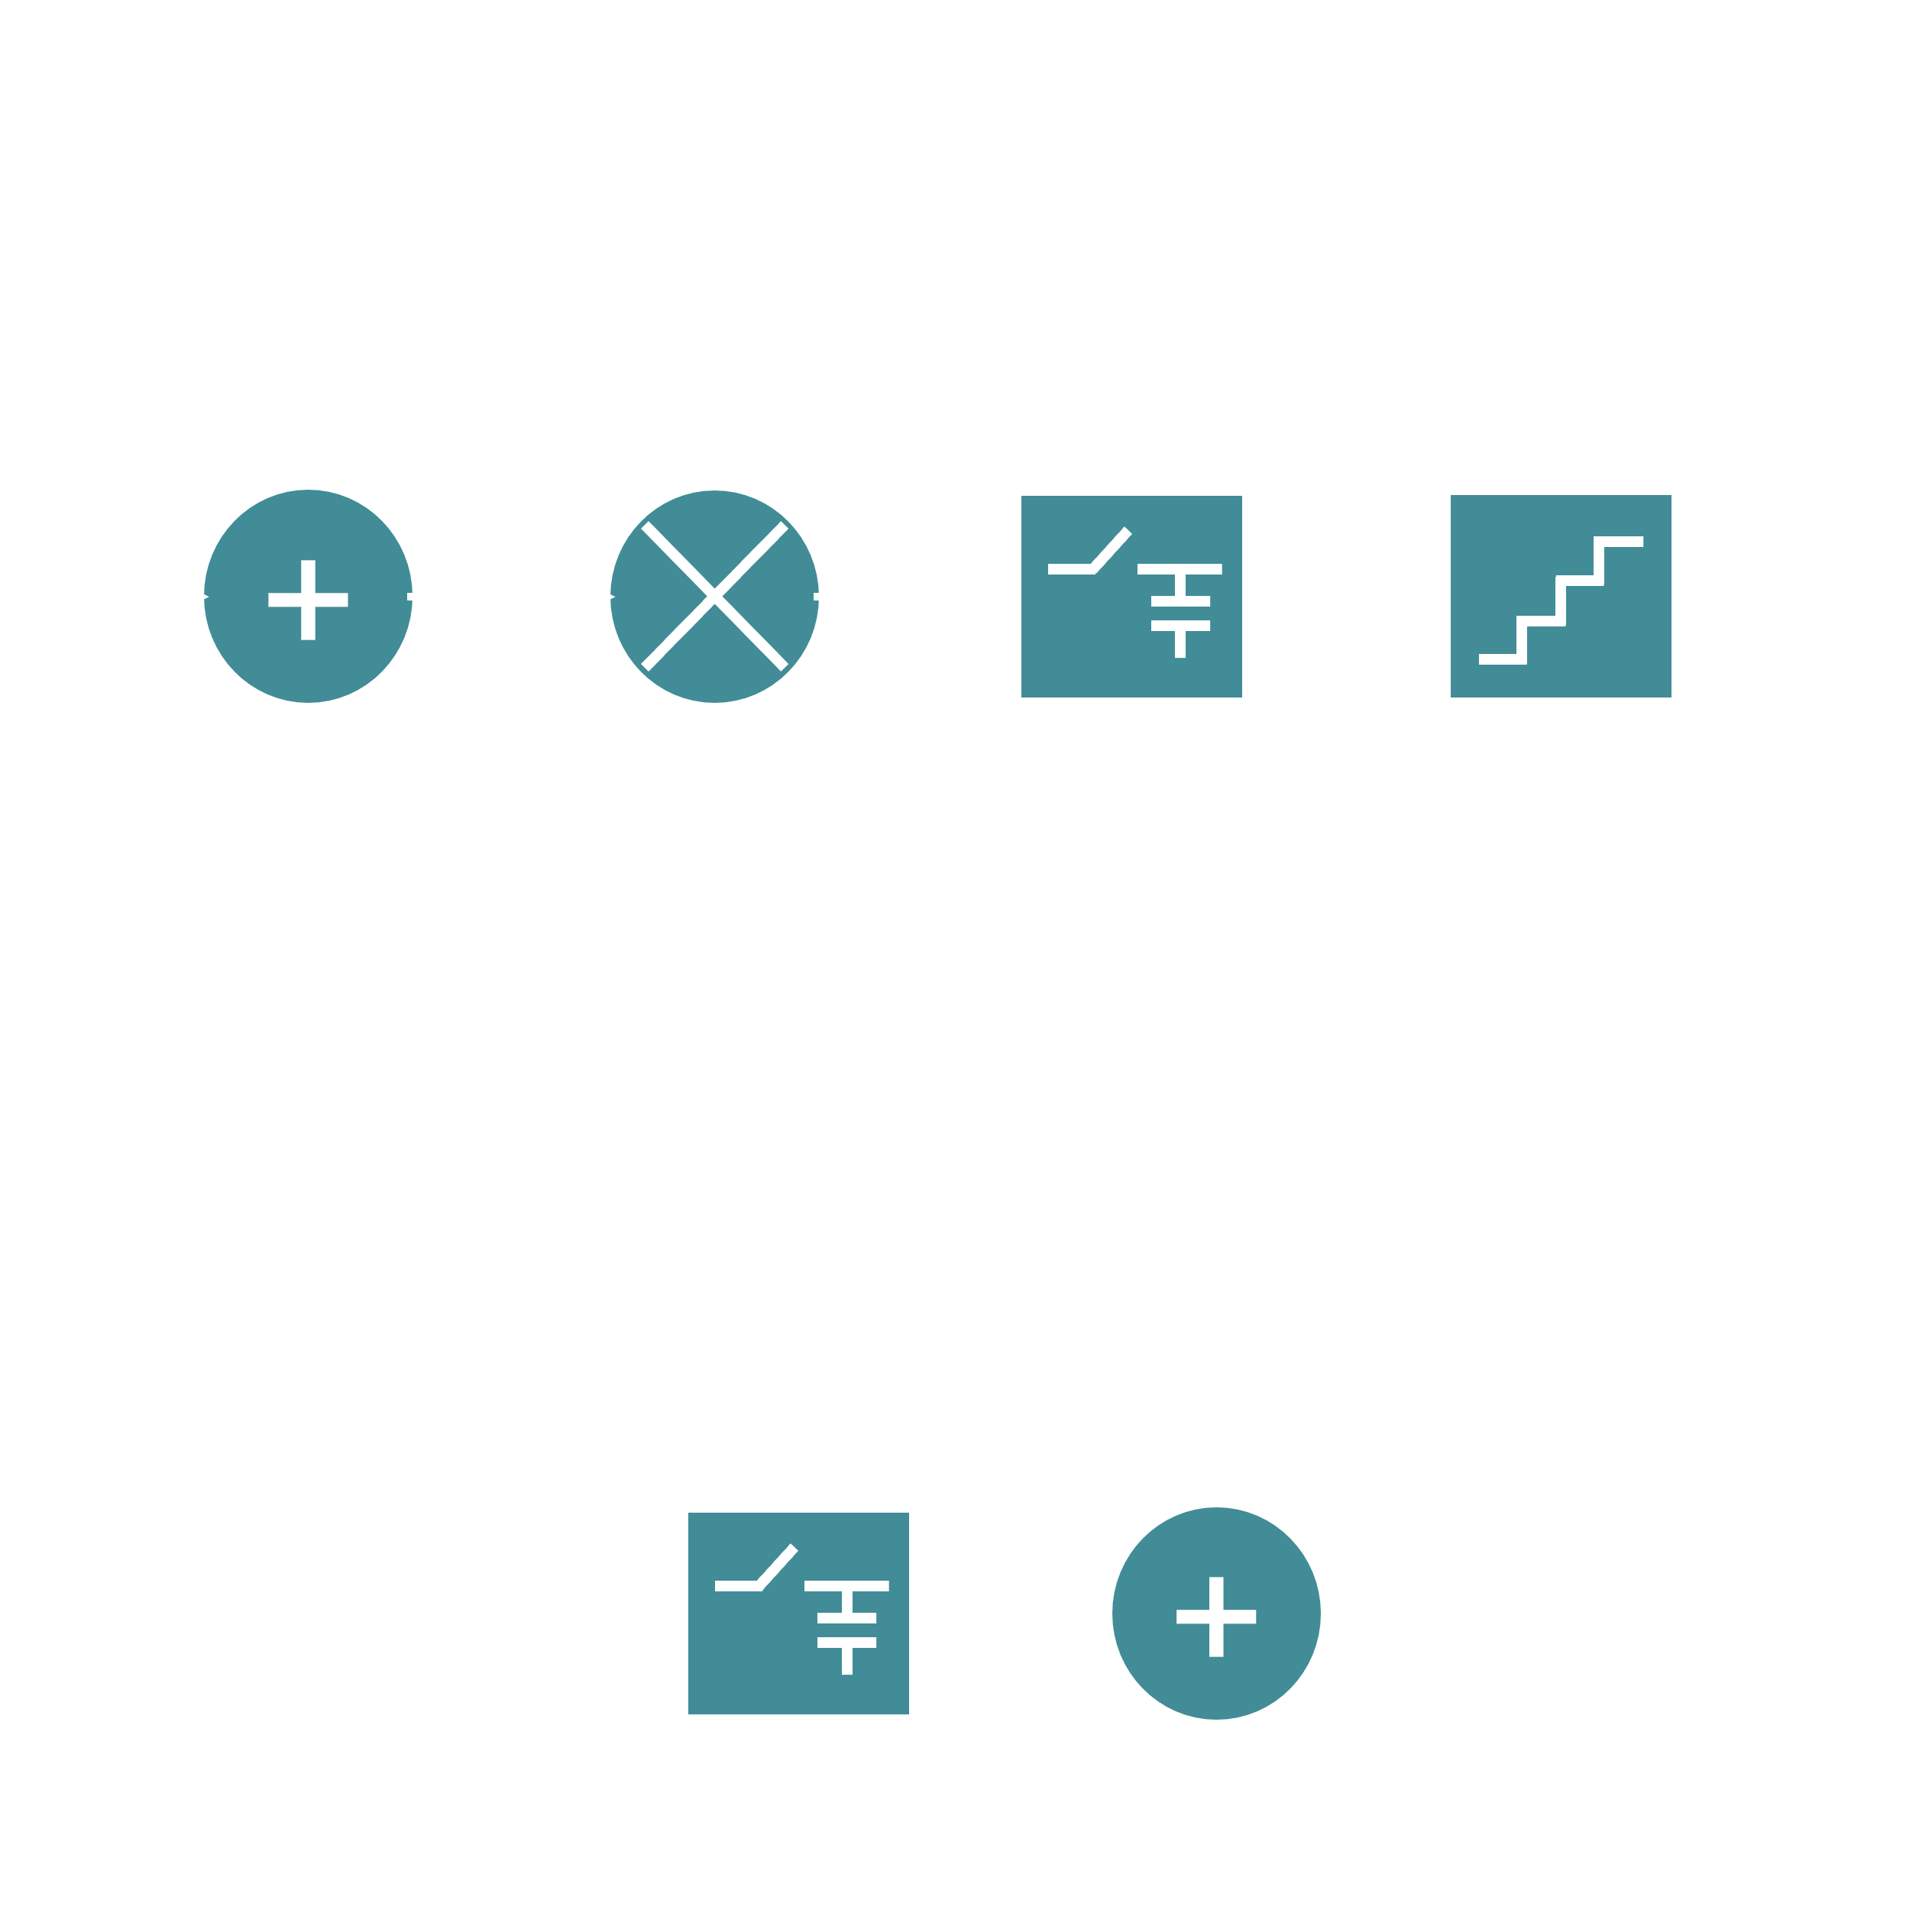
</div>

The figure below shows two ADC models, one per row, driven by the same tone:

- **Row 1 - Real ADC:** the model above, with all impairments active. Its SINAD/ENOB is what you'd actually measure.
- **Row 2 - Ideal reference:** a quantization-noise-only ADC whose noise power is set from the real ADC's measured ENOB, so its SINAD matches Row 1 by construction. It answers: *"a perfect ADC of how many bits gives this same performance?"*

Use the sliders to add impairments to Row 1 and watch its ENOB drop; Row 2 tracks it as the equivalent ideal resolution.


In [ ]:
import numpy as np
import scipy as sp
from ipywidgets import interactive_output, Layout, GridspecLayout
import ipywidgets as widgets
from IPython.display import display, HTML
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sys

# --- Responsive layout -------------------------------------------------------
# The figure reflows from a 2x2 grid (desktop) to a single stacked column
# (phone) so each plot gets the full width, and the controls stack. The real
# viewport width is discovered at RUN TIME by a small anywidget probe (see the
# bottom of the cell): the kernel runs in a Web Worker with no `window`, so it
# can't read the width itself -- the probe's front-end JS (main thread) reports
# it back. set_layout() fills in the globals the builders below read.
NARROW_MAX_PX = 768
LAYOUT = 'wide'
N_ROWS = N_COLS = None
PANELS = {}

def set_layout(layout):
    global LAYOUT, N_ROWS, N_COLS, PANELS, fig_min_width, fig_height
    LAYOUT = layout
    if layout == 'narrow':
        N_ROWS, N_COLS = 4, 1
        PANELS = {'time_real': (1, 1), 'freq_real': (2, 1),
                  'time_ideal': (3, 1), 'freq_ideal': (4, 1)}
        fig_min_width, fig_height = '0px', 1300
    else:
        N_ROWS, N_COLS = 2, 2
        PANELS = {'time_real': (1, 1), 'freq_real': (1, 2),
                  'time_ideal': (2, 1), 'freq_ideal': (2, 2)}
        fig_min_width, fig_height = '900px', 490

set_layout('wide')   # defaults; the probe upgrades to 'narrow' on phones (see bottom)

# The trace *add order* is identical in both layouts (real row's 9 traces, then
# ideal row's 9), so the flat indices set_row() uses never change -- only which
# (row, col) each of the four plot panels lands in (from PANELS above).

# Parameters

# Parameters
fs = 256.3
N  = 2**12
M  = 81                # cycles of fc in the record. Odd -> coprime with N=4096 (a power of two).
"""
Combined with fc below being bin-aligned, this gives coherent sampling:
no spectral leakage (the tone lands exactly on FFT bin M), and the
quantizer-error phase pattern doesn't repeat short-period, so it
decorrelates from the input about as well as an undithered quantizer can.
References:
  - Doernberg, Lee, Hodges, "Full-speed testing of A/D converters,"
    IEEE J. Solid-State Circuits, vol. SC-19, no. 6, 1984 -- the paper
    that established this M-relatively-prime-to-N coherent-sampling method
  - IEEE Std 1241-2010, Annex B ("Coherent sampling")
  - Kester, "MT-003: Understand SINAD, ENOB, SNR, THD, THD+N, and SFDR so
    You Don't Get Lost in the Noise Floor," Analog Devices tutorial (free
    PDF) -- practical walkthrough of the same technique
"""
fc = M * fs / N         # bin-aligned: fc*N/fs == M exactly, so the tone lands on FFT bin M
Vrms = 1
A = Vrms * np.sqrt(2)
border = ''
footer_height = '24px'
include_fc_lobes = 0
# fig_min_width / fig_height are chosen per-layout by set_layout() (top of cell).

# Defaults
bits_default         = 16
n0_default           = -200
d_default             = 1
jitter_default        = 0
jitter_alpha_default  = 4   # 0 = RJ (white), 1 = flicker (1/f), 2 = 1/f^2, 3 = 1/f^3, 4 = 1/f^4

# Globals
kwargs      = {}
fig         = None
widget_dict = None
_jitter_mem = {0: jitter_default, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0}   # remembered magnitude per jitter type; all summed

# Dark theme for widgets, to match the plotly_dark figure

DARK_CSS = """
<style>
.jupyter-widgets, .widget-label, .widget-html-content, .widget-readout {
    color: #e0e0e0 !important;
}
.widget-box, .widget-hbox, .widget-vbox, .widget-gridbox,
.jp-OutputArea-output.jupyter-widgets-view, .cell-output-ipywidget-background {
    background-color: #1e1e1e !important;
}
.widget-readout {
    background-color: #2b2b2b !important;
}
.widget-hslider .slider-container, .ui-slider {
    background-color: #3a3a3a !important;
}
.ui-slider-handle {
    background-color: #4e9af1 !important;
    border-color: #4e9af1 !important;
}
input[type="range"], input[type="checkbox"] {
    accent-color: #4e9af1;
}
@media (max-width: 768px) {
    /* Fit-to-width safety net: if the build-time width probe ever misses, let
       the figure shrink to the viewport anyway (the real reflow to a single
       column is chosen in Python via the 'narrow' layout). */
    .enob-figure { min-width: 0 !important; width: 100% !important; }
}
</style>
"""
display(HTML(DARK_CSS))

# Computation layer (logic unchanged from original)

def calc_metrics(**kw):
    SINAD_t = 20 * np.log10(np.sqrt(np.mean(kw['x']**2)) / np.sqrt(np.var(kw['q_e'])))
    ENOB_t  = (SINAD_t - 1.76) / 6.02
    peak_mag = 10**(kw['peak'][~np.isnan(kw['peak'])] / 10)
    NAD_mag  = 10**(kw['NAD'][~np.isnan(kw['NAD'])]   / 10)
    Ps   = fs/N * np.sum(peak_mag)
    Pnad = fs/N * np.sum(NAD_mag)
    Px   = fs/N * (np.sum(peak_mag) + np.sum(NAD_mag))
    SINAD_f = 10 * np.log10(Ps / Pnad)
    ENOB_f  = (SINAD_f - 1.76) / 6.02
    return {**kw, 'SINAD_t': SINAD_t, 'ENOB_t': ENOB_t,
            'SINAD_f': SINAD_f, 'ENOB_f': ENOB_f,
            'Ps': Ps, 'Pnad': Pnad, 'Px': Px}

def _colored_noise(n, alpha):
    # Spectral-synthesis 1/f^alpha noise: shape a white spectrum by f^(-alpha/2)
    # (so the PSD, which is amplitude squared, comes out ~ 1/f^alpha) and
    # invert back to the time domain. DC bin is zeroed (no meaningful "0 Hz"
    # jitter offset) and the result is normalized to unit RMS so callers can
    # scale it like any other jitter term.
    w   = np.fft.rfft(np.random.randn(n))
    f   = np.fft.rfftfreq(n)
    mag = np.zeros_like(f)
    mag[1:] = f[1:] ** (-alpha / 2)
    c = np.fft.irfft(w * mag, n=n)
    return c / np.std(c)

def time_domain(**kw):
    d   = kw['d']**4
    t   = np.arange(N) / fs
    x   = A * np.sin(2 * np.pi * fc * t)
    dt  = np.zeros(N)
    for jalpha, mag in kw['jitter_mem'].items():        # sum every jitter type's remembered magnitude
        if mag == 0:
            continue
        noise = np.random.randn(N) if jalpha == 0 else _colored_noise(N, alpha=jalpha)
        dt += (mag / fs) * noise                        # aperture jitter / phase noise, in UI (fraction of Ts)
    x_j = A * np.sin(2 * np.pi * fc * (t + dt))          # signal as actually sampled
    x_n = np.sqrt(10**(kw['n0']/10)) * np.random.randn(N)
    x_jn = x_j + x_n                                     # input-referred noise, ahead of the nonlinearity:
    a   = [1, -0.1, -0.1]                                # a real INL/harmonic distortion curve is a memoryless
    x_d = a[0]*x_jn + d*a[1]*x_jn**2 + d*a[2]*x_jn**3 + d*0.01*x_jn**11   # function of whatever voltage hits it
    s   = np.sqrt(np.mean(x**2)) / np.sqrt(np.mean(x_d**2))
    x_d = s * x_d
    q   = A / (2**(kw['bits']-1))
    q_n = (q / np.sqrt(12)) * np.random.randn(N)
    if kw.get('ideal_q', False):
        # Bypass discrete rounding: inject AWGN at the textbook quantization-
        # noise power (q^2/12) instead. This is the model ENOB is defined
        # against, and unlike round()-based quantization it stays well-behaved
        # for the fractional/negative bit counts an impaired ADC's ENOB can
        # produce (round() collapses to the same handful of codes for any
        # 'bits' in a given bracket; this scales continuously instead).
        x_q = x_d + q_n
    else:
        x_q = A*np.round(x_d/A * (2**(kw['bits']-1)-1)) / (2**(kw['bits']-1)-1)
    q_e = x - x_q
    return {**kw, 't': t, 'x': x, 'x_q': x_q, 'q_e': q_e, 'q_n': q_n,
            'levels': 2**kw['bits'] - 1}

def frequency_domain(**kw):
    f     = sp.fft.fftfreq(N, 1/fs)[:N//2]
    w     = sp.signal.windows.kaiser(N, beta=14)
    c_w   = abs(sum(w))
    c_d   = np.sqrt(sum(w**2))
    ssfft = lambda x: 2/c_w * sp.fft.fft(x*w)[:N//2]
    psd   = lambda x: 1/fs * np.abs(c_w*(x/np.sqrt(2))/c_d)**2
    to_db = lambda x: 10*np.log10(psd(ssfft(x)))
    return {**kw, 'f': f,
            'X':   to_db(kw['x']),
            'X_q': to_db(kw['x_q']),
            'Q_e': to_db(kw['q_e']),
            'Q_n': to_db(kw['q_n']),
            'w':   w}

def split_spectrum(**kw):
    dX   = np.diff(kw['X'])
    zc   = np.where(np.diff(np.sign(dX)))[0]
    ll   = include_fc_lobes
    ctr  = np.argmin(np.abs(fc - kw['f'][zc]))
    p0, p1 = zc[ctr-(2*ll+1)], zc[ctr+(2*ll+1)]
    pmask  = np.array([False]*p0 + [True]*(p1-p0+1) + [False]*(len(kw['X'])-p1-1))
    dX_q   = np.diff(kw['X_q'][:p0])
    if dX_q[0] >= 0:
        dmask = np.array([False]*len(kw['X']))
    else:
        dc_end = np.nonzero(np.diff(np.sign(dX_q)))[0][0] + 2 - 1
        dmask  = np.array([True]*dc_end + [False]*(len(kw['X'])-dc_end))
    peak = np.where(pmask,           kw['X_q'], np.nan)
    NAD  = np.where(~pmask & ~dmask, kw['X_q'], np.nan)
    DC   = np.where(dmask,           kw['X_q'], np.nan)
    return {**kw, 'peak': peak, 'NAD': NAD, 'DC': DC}

def compute_row(base_kw):
    F_M     = 18
    f_keys  = ['X', 'X_q', 'Q_e', 'Q_n']
    results = [frequency_domain(**time_domain(**base_kw)) for _ in range(F_M)]
    stacked = {k: np.stack([r[k] for r in results]) for k in f_keys}
    # Average in LINEAR power, not dB. frequency_domain returns dB (to_db), and
    # averaging dB values of a *random* noise floor is biased LOW by ~2.5 dB
    # (Jensen / log-of-exponential: E[10log10 P] = 10log10 E[P] - 10*gamma/ln10,
    # ~2.51 dB). That bias inflated the ideal row's SINAD/ENOB -- its floor is
    # random Gaussian quant noise, fresh each of the F_M runs -- while leaving
    # the real row (deterministic, coherent quantization spurs, identical every
    # run) untouched, so the ideal row read ~0.4 bit better for no real reason.
    # Averaging linear power first, then converting back to dB, removes it.
    avg     = {k: 10*np.log10(np.mean(10**(stacked[k]/10), axis=0)) for k in f_keys}
    merged  = {**results[0], **avg}
    merged  = split_spectrum(**merged)
    merged  = calc_metrics(**merged)
    return merged

# Widget setup

C = {'x':  '#4e9af1', 'xq': '#f0883e', 'qe': '#4ec94e', 'qn': '#e05252',
     'X':  '#4e9af1', 'pk': '#f0883e', 'nd': '#e05252', 'dc': '#9b72d0', 'Qn': '#8ec994'}

def _build_fig():
    global fig
    # Two layouts share one trace-add order (real row's 9 traces, then ideal
    # row's 9) so set_row()'s flat indices never change -- only which (row, col)
    # each panel lands in, taken from PANELS:
    #   wide   -> Time | Frequency columns  x  Real / Ideal rows  (2x2)
    #   narrow -> all four plots stacked in a single column       (4x1)
    # so on a phone each plot uses the full width instead of half.
    specs = [[{"type": "xy"} for _ in range(N_COLS)] for _ in range(N_ROWS)]
    sub_kw = dict(rows=N_ROWS, cols=N_COLS, specs=specs,
                  horizontal_spacing=0.08,
                  vertical_spacing=0.10 if LAYOUT == 'narrow' else 0.12)
    if LAYOUT != 'narrow':
        sub_kw['column_widths'] = [0.5, 0.5]
    fig = go.FigureWidget(make_subplots(**sub_kw))

    def add_row(model, SL):
        tr, cr = PANELS['time_' + model]     # this model's time panel (row, col)
        fr, cf = PANELS['freq_' + model]     # this model's freq panel (row, col)
        # time domain -- traces off+0..off+3
        fig.add_trace(go.Scatter(name='x (Ideal)',        line=dict(color=C['x']),                                    showlegend=SL), row=tr, col=cr)
        fig.add_trace(go.Scatter(name='x_q (Quantized)',  line=dict(color=C['xq']),                                   showlegend=SL), row=tr, col=cr)
        fig.add_trace(go.Scatter(name='q_e (Quant Err)',  mode='markers', marker=dict(size=2, color=C['qe']), visible=False, showlegend=SL), row=tr, col=cr)
        fig.add_trace(go.Scatter(name='q_n (Ideal Noise)',mode='markers', marker=dict(size=2, color=C['qn']), visible=False, showlegend=SL), row=tr, col=cr)
        # freq domain -- traces off+4..off+8
        fig.add_trace(go.Scatter(name='X (Ideal)',   line=dict(color=C['X']),                showlegend=SL), row=fr, col=cf)
        fig.add_trace(go.Scatter(name='X_q Signal',  line=dict(dash='dash', color=C['pk']), showlegend=SL), row=fr, col=cf)
        fig.add_trace(go.Scatter(name='X_q NAD',     line=dict(dash='dash', color=C['nd']), showlegend=SL), row=fr, col=cf)
        fig.add_trace(go.Scatter(name='X_q DC',      line=dict(dash='dash', color=C['dc']), showlegend=SL), row=fr, col=cf)
        fig.add_trace(go.Scatter(name='Ideal q_n',   line=dict(color=C['Qn']),  visible=False, showlegend=SL), row=fr, col=cf)

    add_row('real',  True)   # data[0..8]  (real, r0)
    add_row('ideal', False)  # data[9..17] (ideal, r1)

    fig.update_layout(
        template='plotly_dark',
        autosize=True,
        height=fig_height,
        margin=dict(l=55, r=15, t=80, b=70),
        # Legend along the bottom. Pull it closer to the plots on narrow screens
        # (the tall stacked figure leaves a lot of paper-space below otherwise).
        legend=dict(orientation='h', yanchor='top',
                    y=(-0.05 if LAYOUT == 'narrow' else -0.16),
                    xanchor='center', x=0.5, font=dict(size=10)),
    )

    # Axis titles. Wide: the two plots in each column share an x-axis, so only
    # the bottom row shows tick labels + an x-title. Narrow: every stacked plot
    # stands alone, so each gets its own x-title. y-titles + automargin on all.
    for model in ('real', 'ideal'):
        tr, cr = PANELS['time_' + model]
        fr, cf = PANELS['freq_' + model]
        fig.update_yaxes(title_text='Amplitude (V)', row=tr, col=cr, automargin=True)
        fig.update_yaxes(title_text='PSD [dBW/Hz]',  row=fr, col=cf, automargin=True)
    if LAYOUT == 'narrow':
        for model in ('real', 'ideal'):
            tr, cr = PANELS['time_' + model]
            fr, cf = PANELS['freq_' + model]
            fig.update_xaxes(title_text='Time [s]',       row=tr, col=cr)
            fig.update_xaxes(title_text='Frequency [Hz]', row=fr, col=cf)
    else:
        fig.update_xaxes(showticklabels=False, row=PANELS['time_real'][0],  col=PANELS['time_real'][1])
        fig.update_xaxes(showticklabels=False, row=PANELS['freq_real'][0],  col=PANELS['freq_real'][1])
        fig.update_xaxes(title_text='Time [s]',       row=PANELS['time_ideal'][0], col=PANELS['time_ideal'][1])
        fig.update_xaxes(title_text='Frequency [Hz]', row=PANELS['freq_ideal'][0], col=PANELS['freq_ideal'][1])
        # fig_min_width (the figure Output's min-width) stops the two columns
        # from being squeezed so narrow their y-tick labels/titles overlap.

    # Column titles + per-row data lines live INSIDE the figure. ORDER MATTERS:
    # draw_plot updates the two data lines by index (annotations[2], [3]); the
    # two titles (annotations[0], [1]) are static. Keep exactly 4 annotations in
    # both layouts so those indices stay valid.
    def _dom(axis_letter, panel):
        r, c = PANELS[panel]
        idx = (r - 1) * N_COLS + c          # subplot number in row-major order
        return f'{axis_letter} domain' if idx == 1 else f'{axis_letter}{idx} domain'

    if LAYOUT == 'narrow':
        # Each stacked plot is labeled by its own axis titles, so the
        # "Time/Frequency Domain" column headers are dropped here (they'd
        # collide with the x-axis title of the plot above). annotations[0]/[1]
        # are kept as empty placeholders so draw_plot's index-based writes to
        # [2]/[3] (the per-section SINAD/ENOB lines) stay valid. The data lines
        # get an opaque background so they read clearly in the tight gaps.
        fig.add_annotation(text='', xref='paper', x=0, yref='paper', y=0, showarrow=False)
        fig.add_annotation(text='', xref='paper', x=0, yref='paper', y=0, showarrow=False)
        _dl = dict(xref='paper', x=0.0, xanchor='left', yanchor='bottom', showarrow=False,
                   font=dict(size=10, color='white'), bgcolor='rgba(30,30,30,0.85)', borderpad=2)
        fig.add_annotation(text='', yref='paper',                 y=1.02, **_dl)   # [2] real: top margin
        fig.add_annotation(text='', yref=_dom('y', 'time_ideal'), y=1.14, **_dl)   # [3] ideal: above row 3
    else:
        fig.add_annotation(text='Time Domain', xref='x domain', x=0.5, xanchor='center',
                           yref='paper', y=1.13, yanchor='bottom', showarrow=False,
                           font=dict(size=15, color='white'))
        fig.add_annotation(text='Frequency Domain', xref='x2 domain', x=0.5, xanchor='center',
                           yref='paper', y=1.13, yanchor='bottom', showarrow=False,
                           font=dict(size=15, color='white'))
        fig.add_annotation(text='', xref='paper', x=0.0, xanchor='left',
                           yref='paper', y=1.02, yanchor='bottom', showarrow=False,
                           font=dict(size=11, color='white'))
        fig.add_annotation(text='', xref='paper', x=0.0, xanchor='left',
                           yref='paper', y=0.47, yanchor='bottom', showarrow=False,
                           font=dict(size=11, color='white'))

    # FigureWidget only exposes Plotly's container-driven 'responsive' resize
    # via the synced _config trait (not a layout property or constructor kwarg).
    fig._config = dict(responsive=True)

    with widget_dict['figure']:
        display(fig)


def widget_setup():
    global widget_dict
    widget_dict = {
        'bits':         widgets.IntSlider(min=2, max=16, step=1, value=bits_default, description='Bits'),
        'n0':           widgets.FloatSlider(min=-200, max=0, step=1, value=n0_default, description='AWGN (dB)'),
        'd':            widgets.FloatSlider(min=0, max=1, step=.1, value=d_default, description='Distortion'),
        'jitter':       widgets.FloatSlider(min=0, max=0.1, step=0.001, value=jitter_default,
                                             description='1/f^4 (a=4)', readout_format='.3f'),
        'jitter_alpha': widgets.Dropdown(options=[('1/f^4 (a=4)', 4), ('1/f^3 (a=3)', 3), ('1/f^2 (a=2)', 2),
                                                   ('1/f (a=1)', 1), ('RJ (a=0)', 0)],
                                          value=jitter_alpha_default, description='Jitter:'),
        'q_e_en': widgets.Checkbox(value=False, description='', indent=False,
                                    layout=Layout(width='auto', height='22px', justify_content='center', align_items='center', border=border)),
        'q_n_en': widgets.Checkbox(value=False, description='', indent=False,
                                    layout=Layout(width='auto', height='22px', justify_content='center', align_items='center', border=border)),
        # min_width guards the y-axis-label overlap in wide mode; it is set to
        # '0px' in the narrow layout so the figure can shrink to the phone.
        'figure': widgets.Output(layout=Layout(width='100%', height='100%', min_width=fig_min_width, border=border)),
        'x0lim':  widgets.FloatSlider(min=1, max=np.ceil(fc*N/fs), step=1, value=4, description='XLim (T)',
                                       layout=Layout(height=footer_height, width='100%', border=border)),
        'y0lim':  widgets.FloatRangeSlider(min=-2, max=2, step=0.1, value=(-2, 2), description='YLim (V)',
                                            layout=Layout(height=footer_height, width='100%', border=border)),
        'x1lim':  widgets.FloatSlider(min=np.round(fc), max=fs/2, step=1, value=fs/4, description='XLim (Hz)',
                                       layout=Layout(height=footer_height, width='100%', border=border)),
        'y1lim':  widgets.FloatRangeSlider(min=-200, max=20, step=0.1, value=(-180, 20), description='YLim (dB)',
                                            layout=Layout(height=footer_height, width='100%', border=border)),
    }

    # CSS hook so the mobile @media rule (injected with DARK_CSS above) can
    # target the figure container specifically.
    widget_dict['figure'].add_class('enob-figure')

    # The single jitter slider edits whichever type the dropdown selects; each
    # type's last-set magnitude is remembered in _jitter_mem and recalled on
    # switch back (time_domain sums all of them).
    _alpha_desc = {0: 'RJ (UI)', 1: '1/f PN (UI)', 2: '1/f^2 PN (UI)', 3: '1/f^3 PN (UI)', 4: '1/f^4 PN (UI)'}

    def _on_jitter_change(change):
        _jitter_mem[widget_dict['jitter_alpha'].value] = change['new']

    def _on_alpha_change(change):
        widget_dict['jitter'].value       = _jitter_mem[change['new']]
        widget_dict['jitter'].description = _alpha_desc[change['new']]

    widget_dict['jitter'].observe(_on_jitter_change, names='value')
    widget_dict['jitter_alpha'].observe(_on_alpha_change, names='value')

    # min_width='0' lets these shrink below their ~300px natural content width
    # into a narrow grid column (grid/flex items otherwise refuse to shrink
    # below content and overflow instead).
    for w in (widget_dict['bits'], widget_dict['n0'], widget_dict['d'], widget_dict['jitter']):
        w.layout = Layout(width='100%', min_width='0', border=border)
    widget_dict['jitter_alpha'].layout = Layout(justify_content='center', width='90%', min_width='0', border=border)

    q_e_box = widgets.HBox([widget_dict['q_e_en'], widgets.Label(value='Show Q_e')],
                           layout=Layout(justify_content='center', width='100%', min_width='0', border=border))
    q_n_box = widgets.HBox([widget_dict['q_n_en'], widgets.Label(value='Show Q_n')],
                           layout=Layout(justify_content='center', width='100%', min_width='0', border=border))

    if LAYOUT == 'narrow':
        # Phones: stack every control vertically so each is full-width and
        # touch-friendly. Built as VBoxes (not the desktop GridspecLayouts) so
        # the same widgets aren't re-parented into two containers.
        header_box = widgets.VBox([widget_dict['bits'], widget_dict['n0'],
                                   widget_dict['d'], widget_dict['jitter']],
                                  layout=Layout(width='100%'))
        enable_box = widgets.VBox([q_e_box, q_n_box, widget_dict['jitter_alpha']],
                                  layout=Layout(width='100%'))
        axis_box   = widgets.VBox([widget_dict['x0lim'], widget_dict['x1lim'],
                                   widget_dict['y0lim'], widget_dict['y1lim']],
                                  layout=Layout(width='100%'))
    else:
        # Desktop: header sliders split the full width in a 1x4 grid; the
        # enable/jitter row sits under them; the axis-limit sliders span the
        # full width and split 50/50 under the two plot columns.
        header_box = GridspecLayout(1, 4, layout=Layout(height='100%', overflow='visible'))
        header_box[0, 0] = widget_dict['bits']
        header_box[0, 1] = widget_dict['n0']
        header_box[0, 2] = widget_dict['d']
        header_box[0, 3] = widget_dict['jitter']

        enable_box = GridspecLayout(1, 4, layout=Layout(height='100%', overflow='visible'))
        enable_box[0, 0] = q_e_box
        enable_box[0, 1] = q_n_box
        enable_box[0, 3] = widget_dict['jitter_alpha']

        ax_grids = 5
        x_slider_grid = GridspecLayout(1, ax_grids, layout=Layout(overflow='visible'))
        x_slider_grid[0, :] = widgets.HBox([widget_dict['x0lim'], widget_dict['x1lim']],
                                            layout=Layout(justify_content='center', width='100%', border=border))
        y_slider_grid = GridspecLayout(1, ax_grids, layout=Layout(overflow='visible'))
        y_slider_grid[0, :] = widgets.HBox([widget_dict['y0lim'], widget_dict['y1lim']],
                                            layout=Layout(justify_content='center', width='100%', border=border))
        axis_box = widgets.VBox([x_slider_grid, y_slider_grid])

    grid = GridspecLayout(19, 3, grid_gap='0px',
                           layout=widgets.Layout(align_content='stretch', justify_content='space-around', border=border))

    grid[0, :]    = header_box
    grid[1, :]    = enable_box
    grid[2:-1, :] = widget_dict['figure']
    grid[-1:, :]  = axis_box

    # Row-height tracks. The 16 figure rows sum to fig_height so the Output
    # track matches the plotly height exactly (no scrollbar / no slack). On
    # narrow screens the stacked control rows need more than the fixed 36/56px,
    # so let them auto-size to content. Must be set AFTER every grid[...]
    # assignment: GridspecLayout.__setitem__ resets grid_template_rows on each
    # cell assignment.
    fig_rows = f'{fig_height/16:g}px ' * 16
    if LAYOUT == 'narrow':
        grid.layout.grid_template_rows = 'auto auto ' + fig_rows + 'auto'
    else:
        grid.layout.grid_template_rows = '36px 36px ' + fig_rows + '56px'

    _build_fig()
    return grid


# Draw callback

def draw_plot(**ui):
    global kwargs
    kwargs = {**kwargs, **ui}
    kwargs['jitter_mem'] = dict(_jitter_mem)   # snapshot: every jitter type's remembered magnitude

    r0 = compute_row(dict(kwargs))
    r1 = compute_row({**dict(kwargs), 'bits': r0['ENOB_f'], 'n0': -300, 'd': 0.0,
                       'jitter_mem': {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0}, 'ideal_q': True})

    qe = ui.get('q_e_en', False)
    qn = ui.get('q_n_en', False)

    def set_row(r, off):
        d = fig.data
        d[off+0].x = r['t'];  d[off+0].y = r['x']
        d[off+1].x = r['t'];  d[off+1].y = r['x_q']
        d[off+2].x = r['t'];  d[off+2].y = r['q_e'];  d[off+2].visible = qe
        d[off+3].x = r['t'];  d[off+3].y = r['q_n'];  d[off+3].visible = qn
        d[off+4].x = r['f'];  d[off+4].y = r['X']
        d[off+5].x = r['f'];  d[off+5].y = r['peak']
        d[off+6].x = r['f'];  d[off+6].y = r['NAD']
        d[off+7].x = r['f'];  d[off+7].y = r['DC']
        d[off+8].x = r['f'];  d[off+8].y = r['Q_n'];  d[off+8].visible = qn

    # Per-row data lines (SINAD is a dimensionless ratio -> dB, not dBW).
    if LAYOUT == 'narrow':
        ann0 = f"Real: SINAD {r0['SINAD_f']:.1f} dB · ENOB {r0['ENOB_f']:.2f} b"
        ann1 = f"Ideal ref: SINAD {r1['SINAD_f']:.1f} dB · ENOB {r1['ENOB_f']:.2f} b"
    else:
        ann0 = (f"Real ADC:  N={r0['bits']:.3g} b (nominal)  |  "
                f"SINAD={r0['SINAD_f']:.2f} dB  |  ENOB={r0['ENOB_f']:.2f} b")
        ann1 = (f"Ideal ref (quant-noise only):  "
                f"SINAD={r1['SINAD_f']:.2f} dB  |  ENOB={r1['ENOB_f']:.2f} b")

    with fig.batch_update():
        set_row(r0, 0)
        set_row(r1, 9)
        for _r, _c in (PANELS['time_real'], PANELS['time_ideal']):
            fig.update_xaxes(range=[0, ui['x0lim']/fc], row=_r, col=_c)
            fig.update_yaxes(range=list(ui['y0lim']),   row=_r, col=_c)
        for _r, _c in (PANELS['freq_real'], PANELS['freq_ideal']):
            fig.update_xaxes(range=[0, ui['x1lim']],    row=_r, col=_c)
            fig.update_yaxes(range=list(ui['y1lim']),   row=_r, col=_c)
        # Update only the two data-line annotations (indices 2, 3); the two
        # column titles (0, 1) are static.
        fig.layout.annotations[2].text = ann0
        fig.layout.annotations[3].text = ann1

# Main -- the kernel is a Web Worker (no `window`), so the true viewport width
# is reported by an anywidget whose front-end JS runs in the browser main
# thread. We render the desktop layout immediately (never blank; works even if
# the probe is unavailable) and rebuild as 'narrow' only if the width says so.

import anywidget
import traitlets

class _ViewportProbe(anywidget.AnyWidget):
    _esm = """
    function render({ model, el }) {
      el.style.display = 'none';
      const report = () => { model.set('width', window.innerWidth || 0); model.save_changes(); };
      report();
    }
    export default { render };
    """
    width = traitlets.Int(0).tag(sync=True)

_app = widgets.Output()
_state = {'layout': None}

def _render_app(layout):
    if layout == _state['layout']:
        return                              # already showing this layout
    _state['layout'] = layout
    set_layout(layout)
    grid = widget_setup()
    out  = interactive_output(draw_plot, {k: v for k, v in widget_dict.items() if k != 'figure'})
    _app.clear_output(wait=True)
    with _app:
        display(grid, out)

def _on_width(change):
    w = change['new']
    if w > 0:
        _render_app('narrow' if w <= NARROW_MAX_PX else 'wide')

_probe = _ViewportProbe()
_probe.observe(_on_width, names='width')

display(_probe, _app)
_render_app('wide')   # immediate default; upgraded to 'narrow' when the probe reports


Output()

In [3]:
# --- Scratch: inspect each remembered jitter type's spectrum and the summed dt histogram ---
# Independent of the main figure -- re-run any time after moving the sliders above.
# Requires the main cell to have run at least once (uses widget_dict, _jitter_mem, _colored_noise, N, fs).
# All remembered magnitudes are summed here, mirroring what time_domain() actually does.
#
# Guarded so it is skipped in the Voici/Pyodide build, where sys.platform == 'emscripten'.
# Keeps this scratch cell usable interactively in Jupyter (CPython) without shipping a
# stray panel -- or its error -- into the deployed app.
import sys
if sys.platform != 'emscripten':
    n_draws = 20   # independent realizations to average the PSD over (same idea as compute_row's F_M)

    def _avg_psd(gen_fn):
        P = None
        for _ in range(n_draws):
            s = gen_fn()
            p = np.abs(np.fft.rfft(s))**2 / N
            P = p if P is None else P + p
        return np.fft.rfftfreq(N, d=1/fs), P / n_draws

    _names = {0: 'RJ (white)', 1: '1/f flicker', 2: '1/f^2 walk', 3: '1/f^3', 4: '1/f^4'}

    f_axis = None
    P_by_alpha = {}
    for a, mag in _jitter_mem.items():
        f_axis, P_by_alpha[a] = _avg_psd(
            lambda a=a, mag=mag: (mag / fs) * (np.random.randn(N) if a == 0 else _colored_noise(N, alpha=a)))

    dt_sum = np.zeros(N)
    for a, mag in _jitter_mem.items():
        dt_sum += (mag / fs) * (np.random.randn(N) if a == 0 else _colored_noise(N, alpha=a))

    dbg = make_subplots(rows=1, cols=2,
                         subplot_titles=("dt component PSD (per remembered magnitude)", "dt histogram (summed)"))

    for a, P in P_by_alpha.items():
        label = f"{_names[a]} (mag={_jitter_mem[a]:.3f})"
        dbg.add_trace(go.Scatter(x=f_axis[1:], y=P[1:], name=label, mode='lines'), row=1, col=1)
    dbg.update_xaxes(type='log', title_text='Frequency [Hz]', row=1, col=1)
    dbg.update_yaxes(type='log', title_text='PSD', row=1, col=1)

    dbg.add_trace(go.Histogram(x=dt_sum, nbinsx=60, name='dt', showlegend=False), row=1, col=2)
    dbg.update_xaxes(title_text='dt [s]', row=1, col=2)

    dbg.update_layout(template='plotly_dark', height=420,
                       legend=dict(orientation='h', y=1.15))
    dbg.show()
